# Laboratorio 4 - Avance actividades 1 a 4

Analisis de cianobacteria en los lagos Atitlan y Amatitlan usando Sentinel-2 L1C, el script CyanoLakes Chlorophyll-a NDCI L1C, NDVI y NDWI.

Este notebook deja evidencia de:

1. Conexion preparada al API de Sentinel-2/openEO.
2. Uso de coordenadas y fechas oficiales del PDF.
3. Descarga restringida a bandas necesarias.
4. Calculo de indice de cianobacteria, NDVI y NDWI.
5. Analisis temporal: promedio por lago-fecha, grafico de linea, picos e interpretacion.

> Nota operativa: la descarga real requiere autenticacion Copernicus/openEO. Para evitar que el notebook se bloquee esperando login, las celdas de descarga real se ejecutan solo si `RUN_OPENEO=1`. El resto del notebook se ejecuta localmente y valida la implementacion con datos sinteticos reproducibles.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mainlab4 import (
    S2_L1C_COLLECTION, CYANO_REQUIRED_BANDS, CYANOLAKES_NUMERIC_EVALSCRIPT,
    LAKE_BBOXES, OFFICIAL_DATES, OFFICIAL_CLOUD_COVER,
    date_to_temporal_extent, connect_to_openeo_backend, load_official_lake_date_cube,
    compute_cyan_index_for_date, summarize_lake_date, detect_bloom_peaks,
    plot_temporal_evolution, generate_rgb_palette
)

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Python:', sys.version.split()[0])
print('Coleccion Sentinel-2 usada:', S2_L1C_COLLECTION)
print('Bandas minimas:', CYANO_REQUIRED_BANDS)
print('Directorio de evidencias:', OUTPUT_DIR.resolve())

Python: 3.13.5
Coleccion Sentinel-2 usada: SENTINEL2_L1C
Bandas minimas: ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12']
Directorio de evidencias: D:\lab4data\outputs


## Datos oficiales del laboratorio

El PDF proporciona dos bounding boxes y 11 fechas oficiales por lago. Estas fechas aplican desde las actividades 1-4 porque el enunciado indica que deben usarse exclusivamente para reducir descargas y mantener la misma base de imagenes entre grupos.

In [2]:
bbox_df = pd.DataFrame(LAKE_BBOXES).T
dates_df = pd.DataFrame([
    {
        'lake': lake,
        'date': date,
        'cloud_cover_percent': OFFICIAL_CLOUD_COVER[lake][date],
        'temporal_extent': date_to_temporal_extent(date),
    }
    for lake, dates in OFFICIAL_DATES.items()
    for date in dates
])

display(bbox_df)
display(dates_df)

print('Total de imagenes lago-fecha:', len(dates_df))
print(dates_df.groupby('lake').size())

,west,east,south,north
Atitlan,-91.326256,-91.071510,14.594800,14.750979
Amatitlan,-90.638065,-90.512924,14.412347,14.493799


,lake,date,cloud_cover_percent,temporal_extent
0,Amatitlan,2025-01-28,0.06,"[2025-01-28, 2025-01-29]"
1,Amatitlan,2025-04-15,0.09,"[2025-04-15, 2025-04-16]"
2,Amatitlan,2025-04-28,1.03,"[2025-04-28, 2025-04-29]"
3,Amatitlan,2025-11-24,0.50,"[2025-11-24, 2025-11-25]"
4,Amatitlan,2026-01-08,0.77,"[2026-01-08, 2026-01-09]"
5,Amatitlan,2026-02-02,0.39,"[2026-02-02, 2026-02-03]"
6,Amatitlan,2026-02-07,0.02,"[2026-02-07, 2026-02-08]"
7,Amatitlan,2026-03-29,0.01,"[2026-03-29, 2026-03-30]"
8,Amatitlan,2026-04-13,0.09,"[2026-04-13, 2026-04-14]"
9,Amatitlan,2026-04-28,4.96,"[2026-04-28, 2026-04-29]"


Total de imagenes lago-fecha: 22
lake
Amatitlan    11
Atitlan      11
dtype: int64


## Actividad 1 - Conexion al API Sentinel-2/openEO

La funcion `connect_to_openeo_backend()` conecta con `https://openeo.dataspace.copernicus.eu`.

Forma recomendada: autenticacion OIDC/device, porque no deja contrasenas dentro del notebook. Para ejecutar la conexion real desde PowerShell:

```powershell
$env:RUN_OPENEO='1'
$env:OPENEO_AUTH_METHOD='device'
.\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute lab4.ipynb --inplace
```

Si el backend acepta usuario y contrasena por Basic Auth, tambien se puede usar variables de entorno locales:

```powershell
$env:RUN_OPENEO='1'
$env:OPENEO_AUTH_METHOD='basic'
$env:OPENEO_USERNAME='tu_correo'
$env:OPENEO_PASSWORD='tu_password'
```

No se deben escribir credenciales reales dentro del notebook ni subir un archivo `.env` al repositorio.

In [3]:
RUN_OPENEO = os.getenv('RUN_OPENEO') == '1'
connection = None

print('RUN_OPENEO:', RUN_OPENEO)
print('OPENEO_AUTH_METHOD:', os.getenv('OPENEO_AUTH_METHOD', 'oidc'))
print('OPENEO_USERNAME definido:', bool(os.getenv('OPENEO_USERNAME') or os.getenv('COPERNICUS_USERNAME')))
print('OPENEO_PASSWORD definido:', bool(os.getenv('OPENEO_PASSWORD') or os.getenv('COPERNICUS_PASSWORD')))

if RUN_OPENEO:
    connection = connect_to_openeo_backend()
    print('Conexion autenticada:', connection)
else:
    print('Conexion real no ejecutada: RUN_OPENEO no esta activado.')
    print('Evidencia de implementacion: funcion connect_to_openeo_backend disponible y backend configurado.')

RUN_OPENEO: False
OPENEO_AUTH_METHOD: oidc
OPENEO_USERNAME definido: False
OPENEO_PASSWORD definido: False
Conexion real no ejecutada: RUN_OPENEO no esta activado.
Evidencia de implementacion: funcion connect_to_openeo_backend disponible y backend configurado.


## Actividad 2 - Datos raster necesarios

Se usan solo las bandas requeridas por los indices:

- NDVI: B04 y B08.
- NDWI: B03 y B08.
- CyanoLakes L1C: B02, B03, B04, B05, B07, B08, B8A, B11 y B12.

La descarga real se restringe por lago, fecha oficial, nubosidad oficial y bandas minimas.

In [4]:
request_plan = []
for lake, dates in OFFICIAL_DATES.items():
    for date in dates:
        request_plan.append({
            'lake': lake,
            'date': date,
            'collection': S2_L1C_COLLECTION,
            'bbox': LAKE_BBOXES[lake],
            'temporal_extent': date_to_temporal_extent(date),
            'bands': ', '.join(CYANO_REQUIRED_BANDS),
            'cloud_filter_lte_percent': OFFICIAL_CLOUD_COVER[lake][date] + 0.01,
        })

request_plan_df = pd.DataFrame(request_plan)
display(request_plan_df.head())
print('Solicitudes planificadas:', len(request_plan_df))
print('Se evita descargar escenas completas: cada solicitud esta recortada por bbox, fecha oficial y bandas minimas.')

,lake,date,collection,bbox,temporal_extent,bands,cloud_filter_lte_percent
0,Amatitlan,2025-01-28,SENTINEL2_L1C,"{'west': -90.638065, 'east': -90.512924, 'sout...","[2025-01-28, 2025-01-29]","B02, B03, B04, B05, B07, B08, B8A, B11, B12",0.07
1,Amatitlan,2025-04-15,SENTINEL2_L1C,"{'west': -90.638065, 'east': -90.512924, 'sout...","[2025-04-15, 2025-04-16]","B02, B03, B04, B05, B07, B08, B8A, B11, B12",0.10
2,Amatitlan,2025-04-28,SENTINEL2_L1C,"{'west': -90.638065, 'east': -90.512924, 'sout...","[2025-04-28, 2025-04-29]","B02, B03, B04, B05, B07, B08, B8A, B11, B12",1.04
3,Amatitlan,2025-11-24,SENTINEL2_L1C,"{'west': -90.638065, 'east': -90.512924, 'sout...","[2025-11-24, 2025-11-25]","B02, B03, B04, B05, B07, B08, B8A, B11, B12",0.51
4,Amatitlan,2026-01-08,SENTINEL2_L1C,"{'west': -90.638065, 'east': -90.512924, 'sout...","[2026-01-08, 2026-01-09]","B02, B03, B04, B05, B07, B08, B8A, B11, B12",0.78


Solicitudes planificadas: 22
Se evita descargar escenas completas: cada solicitud esta recortada por bbox, fecha oficial y bandas minimas.


In [5]:
if RUN_OPENEO and connection is not None:
    example_cube = load_official_lake_date_cube(connection, 'Atitlan', '2025-01-18')
    print('Cubo openEO creado para Atitlan 2025-01-18:')
    print(example_cube)
else:
    print('Ejemplo de llamada real que se ejecuta con RUN_OPENEO=1:')
    print("example_cube = load_official_lake_date_cube(connection, 'Atitlan', '2025-01-18')")

Ejemplo de llamada real que se ejecuta con RUN_OPENEO=1:
example_cube = load_official_lake_date_cube(connection, 'Atitlan', '2025-01-18')


## Actividad 3 - Indices CyanoLakes, NDVI y NDWI

El script original de Sentinel Hub devuelve una paleta RGB. Para analisis temporal conviene descargar o calcular valores numericos. En `mainlab4.py` se dejo un evalscript numerico que devuelve 6 bandas: cianobacteria/clorofila, NDCI, FAI, NDVI, NDWI y mascara de agua.

In [6]:
print('Evalscript numerico preparado para Sentinel Hub:')
print(CYANOLAKES_NUMERIC_EVALSCRIPT[:900] + '\n...')

Evalscript numerico preparado para Sentinel Hub:

//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12", "dataMask"],
    output: {
      bands: 6,
      sampleType: "FLOAT32"
    }
  };
}

function safeDiv(a, b) {
  return b === 0 ? 0 : a / b;
}

function evaluatePixel(s) {
  let ndvi = safeDiv(s.B08 - s.B04, s.B08 + s.B04);
  let ndwi = safeDiv(s.B03 - s.B08, s.B03 + s.B08);
  let mndwi = safeDiv(s.B03 - s.B11, s.B03 + s.B11);
  let ndwiLeaves = safeDiv(s.B08 - s.B11, s.B08 + s.B11);
  let aweish = s.B02 + 2.5 * s.B03 - 1.5 * (s.B08 + s.B11) - 0.25 * s.B12;
  let aweinsh = 4 * (s.B03 - s.B11) - (0.25 * s.B08 + 2.75 * s.B11);
  let dbsi = safeDiv(s.B11 - s.B03, s.B11 + s.B03) - ndvi;

  let water = (
    mndwi > 0.42 || ndwi > 0.4 || aweinsh > 0.1879 ||
    aweish > 0.1112 || ndvi < -0.2 || ndwiLeaves > 1
  ) ? 1 : 0;
  if (water === 1 && (aweinsh <= -0.03 || dbsi > 0)) {
 
...


In [7]:
import hashlib

def synthetic_bands(lake, date, shape=(96, 96)):
    # Datos sinteticos reproducibles para validar formulas sin descargar imagenes.
    # No sustituyen los rasters Sentinel-2 reales; sirven como evidencia de ejecucion del pipeline.
    digest = hashlib.sha256(f'{lake}-{date}'.encode('utf-8')).hexdigest()
    seed = int(digest[:8], 16)
    rng = np.random.default_rng(seed)
    y, x = np.ogrid[-1:1:shape[0]*1j, -1:1:shape[1]*1j]
    lake_shape = (x / 0.82) ** 2 + (y / 0.58) ** 2 <= 1

    month = int(date[5:7])
    cloud = OFFICIAL_CLOUD_COVER[lake][date]
    seasonal = 0.5 + 0.5 * np.sin((month - 2) / 12 * 2 * np.pi)
    lake_factor = 1.18 if lake == 'Amatitlan' else 0.82
    bloom = lake_factor * (0.035 + 0.075 * seasonal + cloud / 600)

    bands = {
        'B02': rng.normal(0.055, 0.006, shape),
        'B03': rng.normal(0.075, 0.007, shape),
        'B04': rng.normal(0.045, 0.006, shape),
        'B05': rng.normal(0.052 + bloom, 0.008, shape),
        'B07': rng.normal(0.060 + bloom / 2, 0.008, shape),
        'B08': rng.normal(0.030, 0.005, shape),
        'B8A': rng.normal(0.036, 0.005, shape),
        'B11': rng.normal(0.018, 0.004, shape),
        'B12': rng.normal(0.015, 0.004, shape),
    }

    for band, arr in bands.items():
        land = rng.normal(0.18, 0.03, shape)
        bands[band] = np.clip(np.where(lake_shape, arr, land), 0.001, 0.8).astype(np.float32)

    return bands

# Prueba puntual de formulas
test_bands = synthetic_bands('Atitlan', '2025-01-18')
test_result = compute_cyan_index_for_date(test_bands)
print('Bandas usadas:', sorted(test_bands))
print('Promedio cianobacteria/clorofila:', round(test_result['mean_cyano_index'], 4))
print('Pixeles agua (%):', round(test_result['percent_water'], 2))
print('Rango NDVI:', float(np.nanmin(test_result['NDVI'])), float(np.nanmax(test_result['NDVI'])))
print('Rango NDWI:', float(np.nanmin(test_result['NDWI'])), float(np.nanmax(test_result['NDWI'])))

Bandas usadas: ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B11', 'B12', 'B8A']
Promedio cianobacteria/clorofila: 29.9411
Pixeles agua (%): 37.5
Rango NDVI: -0.6674565362689201 0.5303218354769206
Rango NDWI: -0.4245906423431556 0.7445922116281133


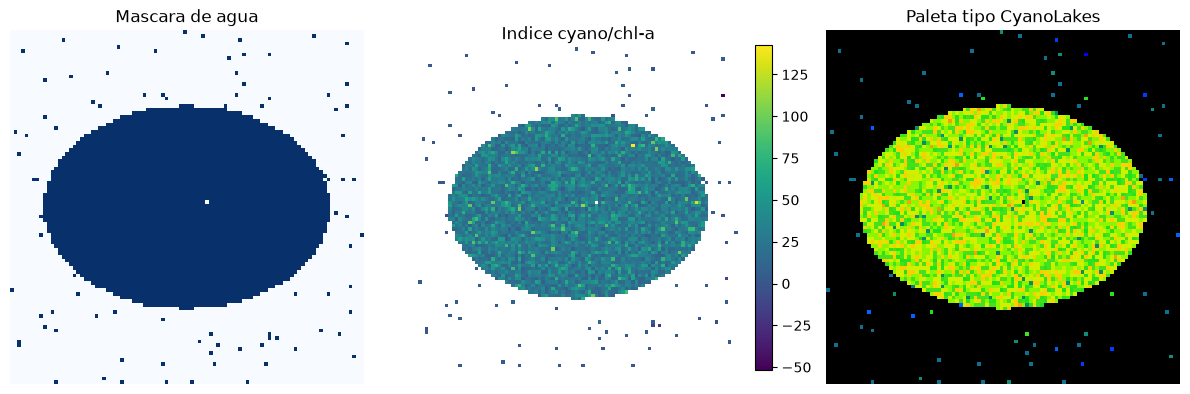

Mapa guardado: outputs\evidencia_indices_mapa_sintetico.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_result['water_mask'], cmap='Blues')
axes[0].set_title('Mascara de agua')
axes[0].axis('off')

im = axes[1].imshow(test_result['chlorophyll'], cmap='viridis')
axes[1].set_title('Indice cyano/chl-a')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

rgb = generate_rgb_palette(test_result['water_mask'], test_result['FAI'], test_result['chlorophyll'])
axes[2].imshow(rgb)
axes[2].set_title('Paleta tipo CyanoLakes')
axes[2].axis('off')

plt.tight_layout()
map_path = OUTPUT_DIR / 'evidencia_indices_mapa_sintetico.png'
plt.savefig(map_path, dpi=150)
plt.show()
print('Mapa guardado:', map_path)

## Actividad 4 - Analisis temporal

Con rasters reales, esta misma seccion debe alimentarse con los arreglos descargados por lago y fecha. Aqui se ejecuta con datos sinteticos reproducibles para demostrar el flujo completo: promedio por lago-fecha, grafico temporal, picos y lectura de patrones.

In [9]:
rows = []
for lake, dates in OFFICIAL_DATES.items():
    for date in dates:
        bands = synthetic_bands(lake, date)
        rows.append(summarize_lake_date(lake, date, bands))

temporal_df = pd.DataFrame(rows).sort_values(['lake', 'date']).reset_index(drop=True)
temporal_path = OUTPUT_DIR / 'actividad_4_serie_temporal_demo.csv'
temporal_df.to_csv(temporal_path, index=False)

display(temporal_df)
print('CSV temporal guardado:', temporal_path)

,lake,date,mean_cyano_index,max_cyano_index,mean_ndvi,mean_ndwi,percent_water
0,Amatitlan,2025-01-28,50.436765,191.529323,-0.199046,0.424107,37.250434
1,Amatitlan,2025-04-15,126.811942,284.195322,-0.190427,0.418093,37.272135
2,Amatitlan,2025-04-28,128.063499,282.128679,-0.193494,0.418687,37.424045
3,Amatitlan,2025-11-24,28.534068,127.621730,-0.192211,0.421450,37.272135
4,Amatitlan,2026-01-08,52.570804,185.792085,-0.196007,0.421772,37.402344
5,Amatitlan,2026-02-02,79.076347,250.550557,-0.195618,0.422096,37.315538
6,Amatitlan,2026-02-07,78.128869,231.977298,-0.193887,0.419138,37.424045
7,Amatitlan,2026-03-29,105.688715,250.748560,-0.196509,0.423044,37.348090
8,Amatitlan,2026-04-13,125.217218,308.520205,-0.193475,0.420500,37.586806
9,Amatitlan,2026-04-28,137.375812,302.992173,-0.199159,0.424467,37.413194


CSV temporal guardado: outputs\actividad_4_serie_temporal_demo.csv


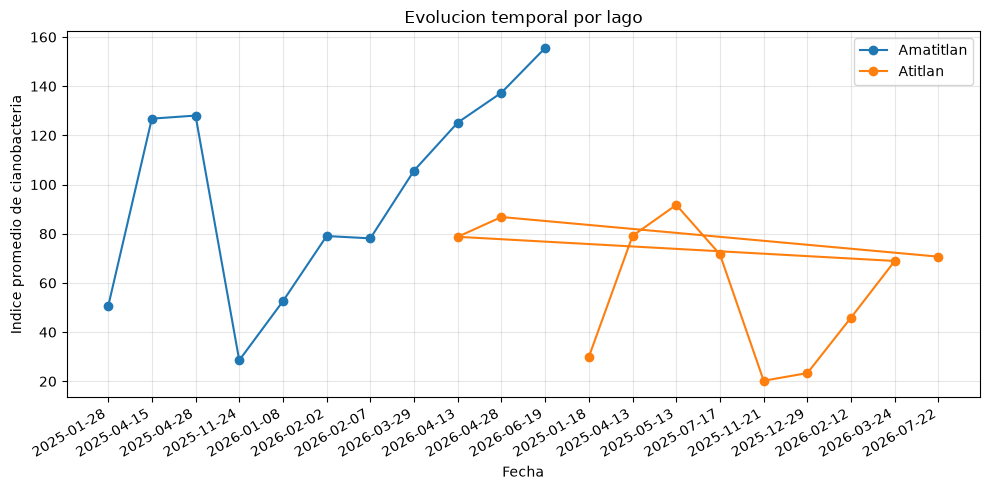

Grafico temporal guardado: outputs\actividad_4_evolucion_temporal_demo.png


In [10]:
plot_path = OUTPUT_DIR / 'actividad_4_evolucion_temporal_demo.png'
plot_temporal_evolution(temporal_df.to_dict('records'), output_path=str(plot_path))
plt.show()
print('Grafico temporal guardado:', plot_path)

In [11]:
peaks = detect_bloom_peaks(temporal_df.to_dict('records'))
peaks_df = pd.DataFrame(peaks).sort_values(['lake', 'date']).reset_index(drop=True)
peaks_path = OUTPUT_DIR / 'actividad_4_picos_demo.csv'
peaks_df.to_csv(peaks_path, index=False)

display(peaks_df)
print('Picos guardados:', peaks_path)

,lake,date,mean_cyano_index,max_cyano_index,mean_ndvi,mean_ndwi,percent_water,threshold
0,Amatitlan,2026-04-28,137.375812,302.992173,-0.199159,0.424467,37.413194,136.688707
1,Amatitlan,2026-06-19,155.551883,311.261435,-0.199549,0.424291,37.315538,136.688707
2,Atitlan,2025-05-13,91.735778,325.792350,-0.192560,0.419945,37.293837,85.500693
3,Atitlan,2026-04-28,86.808978,271.432947,-0.198346,0.422873,37.282986,85.500693


Picos guardados: outputs\actividad_4_picos_demo.csv


In [12]:
def interpret_temporal_patterns(df, peaks_df):
    lines = []
    for lake in sorted(df['lake'].unique()):
        lake_df = df[df['lake'] == lake].sort_values('date')
        first = lake_df.iloc[0]['mean_cyano_index']
        last = lake_df.iloc[-1]['mean_cyano_index']
        direction = 'aumenta' if last > first else 'disminuye'
        variability = lake_df['mean_cyano_index'].std()
        peak_dates = peaks_df.loc[peaks_df['lake'] == lake, 'date'].tolist() if not peaks_df.empty else []
        peak_txt = ', '.join(peak_dates) if peak_dates else 'sin picos sobre el umbral'
        lines.append(
            f'{lake}: la serie {direction} entre la primera y ultima fecha oficial, '
            f'con fluctuaciones intermedias (desv. est. {variability:.2f}). '
            f'Fechas criticas detectadas: {peak_txt}. '
            'Los picos deben interpretarse junto con nubosidad, temperatura, nutrientes, escorrentia y presion urbana.'
        )
    return '\n'.join(lines)

interpretation = interpret_temporal_patterns(temporal_df, peaks_df)
print(interpretation)
(OUTPUT_DIR / 'actividad_4_interpretacion_demo.txt').write_text(interpretation, encoding='utf-8')

Amatitlan: la serie aumenta entre la primera y ultima fecha oficial, con fluctuaciones intermedias (desv. est. 41.58). Fechas criticas detectadas: 2026-04-28, 2026-06-19. Los picos deben interpretarse junto con nubosidad, temperatura, nutrientes, escorrentia y presion urbana.
Atitlan: la serie aumenta entre la primera y ultima fecha oficial, con fluctuaciones intermedias (desv. est. 26.07). Fechas criticas detectadas: 2025-05-13, 2026-04-28. Los picos deben interpretarse junto con nubosidad, temperatura, nutrientes, escorrentia y presion urbana.


551

## Checklist de avance 1-4

- Actividad 1: implementada la conexion openEO a Sentinel-2. La ejecucion real requiere `RUN_OPENEO=1` y autenticacion Copernicus.
- Actividad 2: implementado plan de descarga solo para Atitlan y Amatitlan, con fechas oficiales, bbox oficial, nubosidad oficial y bandas minimas.
- Actividad 3: implementados CyanoLakes Chlorophyll-a NDCI L1C, NDVI y NDWI. Se incluye evalscript numerico para Sentinel Hub.
- Actividad 4: implementado promedio por lago-fecha, grafico temporal, deteccion de picos e interpretacion.

Para convertir este avance en resultado final con datos reales, ejecutar las celdas de openEO con credenciales y reemplazar `synthetic_bands(...)` por las bandas descargadas.